<a href="https://colab.research.google.com/github/anyuanay/INFO213/blob/main/INFO213_Week7_knn_boundary_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The KNN Boundary Visualizer

**Activity:** Use the slider to change K from 1 to 50 and observe how the KNN decision boundary shifts.
- Observe how the boundary changes shape as K increases
- Compare K=1 vs K=50 — which boundary is overfit and why?
- Write your one-sentence technical justification in the cell at the bottom.

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from ipywidgets import interact, IntSlider, Layout, HBox, VBox, Label
import ipywidgets as widgets
%matplotlib inline

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# Generate a fixed dataset (same seed → same dots every run)
np.random.seed(42)

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.9,
    random_state=42
)

print(f'Dataset: {X.shape[0]} samples, 2 features, 2 classes')
print(f'Class 0 (blue):  {(y==0).sum()} samples')
print(f'Class 1 (orange): {(y==1).sum()} samples')

Dataset: 200 samples, 2 features, 2 classes
Class 0 (blue):  100 samples
Class 1 (orange): 100 samples


In [ ]:
# Build the mesh grid used for boundary shading
RESOLUTION = 300   # increase for sharper boundary (slower)
PADDING     = 0.5

x_min, x_max = X[:, 0].min() - PADDING, X[:, 0].max() + PADDING
y_min, y_max = X[:, 1].min() - PADDING, X[:, 1].max() + PADDING

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, RESOLUTION),
    np.linspace(y_min, y_max, RESOLUTION)
)

# Colour maps
CMAP_BG   = ListedColormap(['#AEC6E8', '#FDDBA0'])   # soft blue / soft orange
COLORS    = ['#2166AC', '#F4A83A']                    # strong blue / strong orange

print('Grid ready.')

Grid ready.


In [ ]:
# Interactive plot function
def plot_knn_boundary(K=1):
    """Train a KNN classifier with k=K and plot the decision boundary."""

    # --- Train ---
    clf = KNeighborsClassifier(n_neighbors=K)
    clf.fit(X, y)
    train_acc = clf.score(X, y) * 100

    # --- Predict on mesh ---
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                              gridspec_kw={'width_ratios': [1.6, 1]})
    fig.patch.set_facecolor('#FAFAFA')

    # ── LEFT PANEL: decision boundary ───────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor('#F5F5F5')

    # Background shading
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=CMAP_BG)

    # Decision boundary contour
    ax.contour(xx, yy, Z, levels=[0.5], colors='#8B0000',
               linewidths=2.0, linestyles='solid')

    # Data points
    for cls, color, label in zip([0, 1], COLORS, ['Class 0', 'Class 1']):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=color, edgecolors='white', linewidths=0.4,
                   s=60, alpha=0.9, label=label, zorder=3)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Feature 1', fontsize=11)
    ax.set_ylabel('Feature 2', fontsize=11)
    ax.set_title(f'KNN Decision Boundary  (K = {K})', fontsize=13, fontweight='bold', pad=10)
    ax.legend(loc='upper left', framealpha=0.85, fontsize=10)
    ax.grid(True, linestyle='--', linewidth=0.4, color='#CCCCCC')

    # ── RIGHT PANEL: info card ───────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#FAFAFA')
    ax2.axis('off')

    # Complexity label
    if K == 1:
        complexity = 'MAXIMUM complexity\n(very likely overfit)'
        bias_text  = '▼ Bias   ▲ Variance'
        card_color = '#FFDDDD'
        border     = '#CC4444'
    elif K <= 5:
        complexity = 'HIGH complexity'
        bias_text  = '▼ Bias   ▲ Variance'
        card_color = '#FFE8CC'
        border     = '#DD8833'
    elif K <= 15:
        complexity = 'MODERATE complexity'
        bias_text  = '~ Bias   ~ Variance'
        card_color = '#FFFACC'
        border     = '#BBAA00'
    elif K <= 30:
        complexity = 'LOW complexity'
        bias_text  = '▲ Bias   ▼ Variance'
        card_color = '#DDEEDD'
        border     = '#448844'
    else:
        complexity = 'VERY LOW complexity\n(risk of underfit)'
        bias_text  = '▲▲ Bias  ▼▼ Variance'
        card_color = '#DDEEDD'
        border     = '#226622'

    # Draw info card
    card = mpatches.FancyBboxPatch((0.05, 0.30), 0.90, 0.60,
                                    boxstyle='round,pad=0.04',
                                    facecolor=card_color,
                                    edgecolor=border, linewidth=2,
                                    transform=ax2.transAxes, zorder=2)
    ax2.add_patch(card)

    ax2.text(0.50, 0.85, f'K = {K}',
             ha='center', va='center', fontsize=32, fontweight='bold',
             transform=ax2.transAxes, color='#222222')
    ax2.text(0.50, 0.68, complexity,
             ha='center', va='center', fontsize=11, fontstyle='italic',
             transform=ax2.transAxes, color='#444444')
    ax2.text(0.50, 0.50, bias_text,
             ha='center', va='center', fontsize=12, fontfamily='monospace',
             transform=ax2.transAxes, color='#333333')
    ax2.text(0.50, 0.37, f'Training Accuracy: {train_acc:.1f}%',
             ha='center', va='center', fontsize=11, fontweight='bold',
             transform=ax2.transAxes, color='#222222')

    # Bias-variance bar
    bar_y   = 0.18
    bar_h   = 0.07
    # background bar
    ax2.add_patch(mpatches.FancyBboxPatch((0.05, bar_y), 0.90, bar_h,
                                          boxstyle='round,pad=0.01',
                                          facecolor='#E0E0E0',
                                          edgecolor='#BBBBBB', linewidth=1,
                                          transform=ax2.transAxes))
    # fill: small K → high complexity → right side of bar lit up in red
    fill_w = 0.90 * (1 - (K - 1) / 49)
    fill_color = plt.cm.RdYlGn(K / 50)
    ax2.add_patch(mpatches.FancyBboxPatch((0.05, bar_y), fill_w, bar_h,
                                          boxstyle='round,pad=0.01',
                                          facecolor=fill_color,
                                          edgecolor='none',
                                          transform=ax2.transAxes))
    ax2.text(0.05, bar_y - 0.04, 'Overfit (K=1)',
             ha='left', va='top', fontsize=8, color='#CC3333',
             transform=ax2.transAxes)
    ax2.text(0.95, bar_y - 0.04, 'Underfit (K=50)',
             ha='right', va='top', fontsize=8, color='#336633',
             transform=ax2.transAxes)

    plt.tight_layout(pad=1.5)
    plt.show()


# ── Widget ──────────────────────────────────────────────────────────────────
k_slider = IntSlider(
    value=1, min=1, max=50, step=1,
    description='K =',
    style={'description_width': '40px'},
    layout=Layout(width='520px')
)

out = widgets.interactive_output(plot_knn_boundary, {'K': k_slider})

header = widgets.HTML(
    value='<h3 style="margin-bottom:4px">🔢 Drag the slider to change K</h3>'
          '<p style="color:#555;margin-top:0">Watch how the decision boundary changes '
          'as K increases from 1 (overfit) to 50 (underfit).</p>'
)

display(VBox([header, k_slider, out]))

## Question:
Which boundary (K=1 or K=50) is overfit, and why?

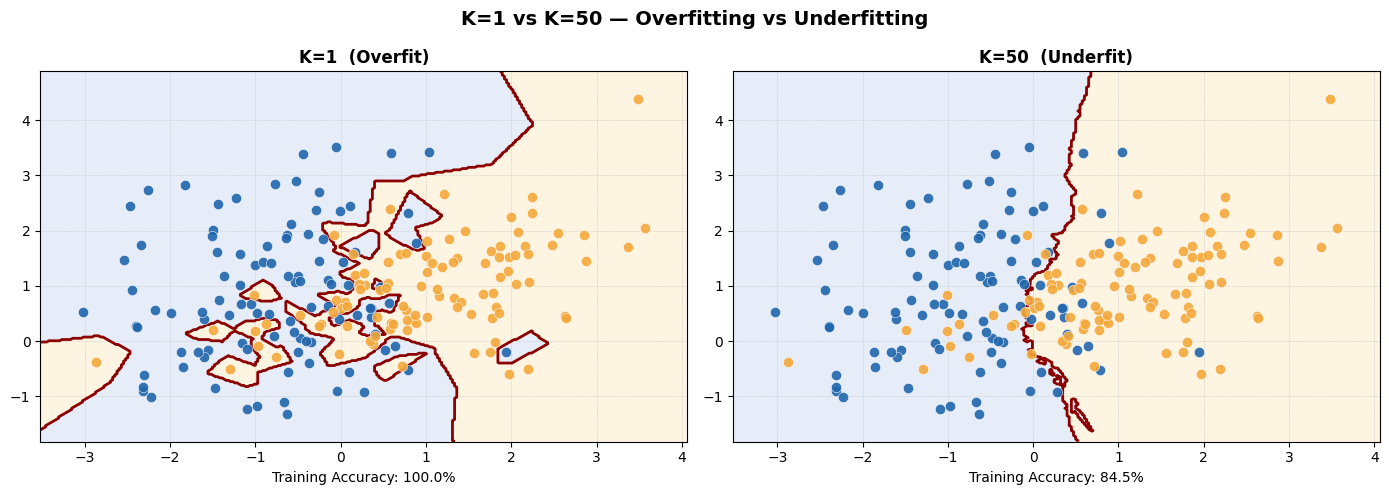

In [ ]:
# Side-by-side K=1 vs K=50 comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K=1 vs K=50 — Overfitting vs Underfitting', fontsize=14, fontweight='bold')

for ax, K, label in zip(axes, [1, 50], ['K=1  (Overfit)', 'K=50  (Underfit)']):
    clf = KNeighborsClassifier(n_neighbors=K)
    clf.fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.30, cmap=CMAP_BG)
    ax.contour(xx, yy, Z, levels=[0.5], colors='#8B0000', linewidths=2.0)

    for cls, color in zip([0, 1], COLORS):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=color, edgecolors='white',
                   linewidths=0.4, s=55, alpha=0.9, zorder=3)

    ax.set_title(label, fontsize=12, fontweight='bold')
    acc = clf.score(X, y) * 100
    ax.set_xlabel(f'Training Accuracy: {acc:.1f}%', fontsize=10)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle='--', linewidth=0.4, color='#CCCCCC')

plt.tight_layout()
plt.show()